In [ ]:
import numpy as np
import pandas as pd

df=pd.read_csv('covid_19_data.csv')
df

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
306424,306425,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0
306425,306426,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0
306426,306427,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0
306427,306428,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0


In [ ]:
#Filter the data to isolate data for a specific country (e.g., Bangladesh).

df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])
filter_data = df[df['Country/Region'] == 'Bangladesh']
print(filter_data['Country/Region'].unique())

<ArrowStringArray>
['Bangladesh']
Length: 1, dtype: str


In [ ]:
#Check if there are any missing or null values in the filtered data.

print("Missing Values per Column==>")
print(filter_data.isnull().sum())

# Add 'Unkonw'
filter_data['Province/State'] = filter_data['Province/State'].fillna('Unkonw')

Missing Values per Column==>
SNo                  0
ObservationDate      0
Province/State     448
Country/Region       0
Last Update          0
Confirmed            0
Deaths               0
Recovered            0
dtype: int64


In [11]:
#1.Extract year and month from the date column, ignoring the days.
#2.Grouping by month to find the maximum number of cases, deaths, and recoveries.
#3.Displaying the newly created dataframe on the screen.

filter_data['Month'] =filter_data['ObservationDate'].dt.to_period('M')

monthly_data= filter_data.groupby('Month').agg({
  'Confirmed':'max',
  'Deaths':'max',
  'Recovered':'max'
}).reset_index()

monthly_data

,Month,Confirmed,Deaths,Recovered
0,2020-03,51.0,5.0,25.0
1,2020-04,7667.0,168.0,160.0
2,2020-05,47153.0,650.0,9781.0
3,2020-06,145483.0,1847.0,59624.0
4,2020-07,237661.0,3111.0,135136.0
5,2020-08,312996.0,4281.0,204887.0
6,2020-09,363479.0,5251.0,275487.0
7,2020-10,407684.0,5923.0,324145.0
8,2020-11,464932.0,6644.0,380711.0
9,2020-12,513510.0,7559.0,457459.0


In [42]:
#Calculating the Death Rate (%) and Recovery Rate (%)

monthly_data['Death_Rate'] = (monthly_data['Deaths'] / monthly_data['Confirmed']) * 100
monthly_data['Recovery_Rate'] = (monthly_data['Recovered'] / monthly_data['Confirmed']) * 100

#Find the month with the maximum death rate.
highest_death=monthly_data.loc[monthly_data['Death_Rate'].idxmax()]

#Analyze the average recovery rate per country across the dataset, highlighting Bangladesh's average
average_Rccovery_Rate=monthly_data['Recovery_Rate'].mean()

#print(monthly_data['Death_Rate'])
#print(monthly_data['Recovery_Rate'])


In [43]:
# 4. Printing the final summary report
print(f"--- Project Summary Report (Bangladesh)---")
print(f"The highest death rate was in the month of: {highest_death['Month']}.")
print(f"The death rate in that month was: {highest_death['Death_Rate']:.2f}%")
print(f"The average recovery rate for Bangladesh throughout the pandemic was: {average_Rccovery_Rate:.2f}%")

--- Project Summary Report (Bangladesh)---
The highest death rate was in the month of: 2020-03.
The death rate in that month was: 9.80%
The average recovery rate for Bangladesh throughout the pandemic was: 67.53%


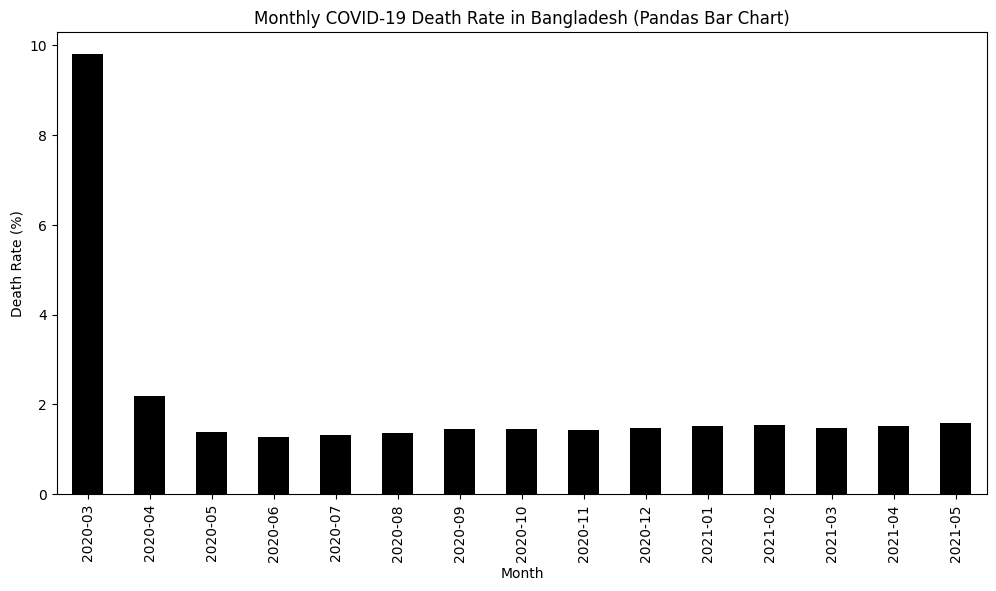

In [44]:
import matplotlib.pyplot as plt

chart_data=monthly_data.set_index('Month')
chart_data['Death_Rate'].plot(kind='bar',color='black',figsize=(12,6))

plt.title('Monthly COVID-19 Death Rate in Bangladesh (Pandas Bar Chart)')
plt.ylabel('Death Rate (%)')
plt.xlabel('Month')

plt.show()